In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
pathes = [
    "/home/artyom/myprojects/ITMO/DML/logs/bert_2_2/version_0/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/bert_2_4/version_0/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/bert_2_8/version_0/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/bert_4_2/version_0/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/bert_4_4/version_0/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/bert_4_8/version_0/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/bert_8_2/version_0/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/bert_8_4/version_0/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/bert_8_8/version_0/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/conformer_2_2/version_1/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/conformer_2_4/version_1/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/conformer_2_8/version_1/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/conformer_4_2/version_1/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/conformer_4_4/version_1/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/conformer_4_8/version_1/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/conformer_8_2/version_1/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/conformer_8_4/version_1/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/conformer_8_8/version_1/metrics.csv",
]

dfs = {}
for file in pathes:
    dfs[str(file)] = pd.read_csv(file)
dfs[pathes[0]]

,epoch,step,test_acc,test_f1,test_loss,test_precision,test_recall,test_roc-auc,train_acc,train_f1,train_loss,train_precision,train_recall,train_roc-auc,val_acc,val_f1,val_loss,val_precision,val_recall,val_roc-auc
0,0,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.065747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.088354,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.863917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.102478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.920484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0,299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.857132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.865311,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.927010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0,449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.805231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0,499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.967690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


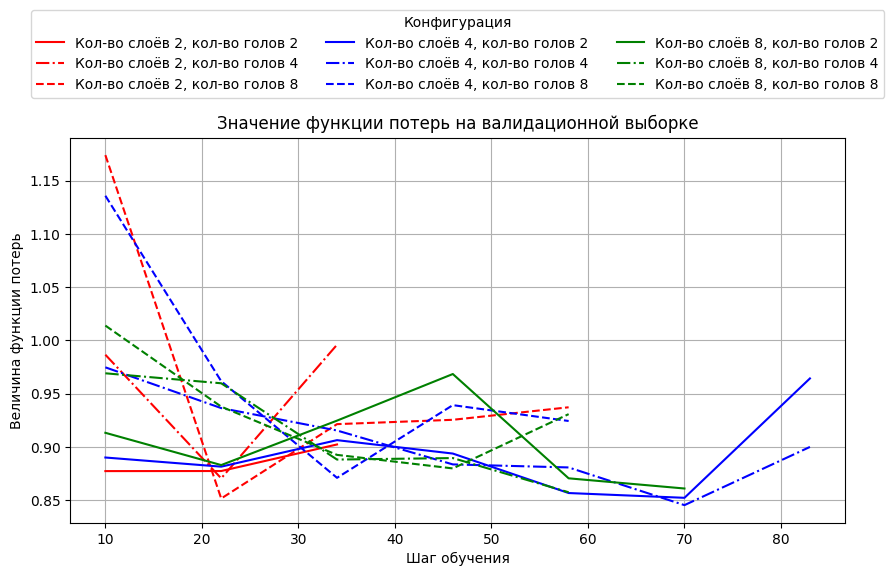

In [ ]:
import math
import re


def extract_ij_from_path(path):
    # Use regex to find the pattern bert_{i}_{j}
    match = re.search(r"bert_(\d+)_(\d+)", path)
    if match:
        i, j = match.groups()
        return int(i), int(j)

    raise ValueError("Path does not contain a valid bert_{i}_{j} pattern.")


plt.figure(figsize=(10, 5))
plt.title("Значение функции потерь на валидационной выборке")
plt.xlabel("Шаг обучения")
plt.ylabel("Величина функции потерь")

linestyles = ["-", "-.", "--"]
colors = ["red", "blue", "green"]
for i in range(9):
    path = pathes[i]
    layers, heads = extract_ij_from_path(path)
    plt.plot(dfs[pathes[i]]["val_loss"].dropna(), label=f"Кол-во слоёв {layers}, кол-во голов {heads}", color=colors[int(math.log2(layers)) - 1], linestyle=linestyles[int(math.log2(heads)) - 1])

plt.grid()
plt.legend(title="Конфигурация", bbox_to_anchor=(0.5, 1.35), loc="upper center", ncol=3)

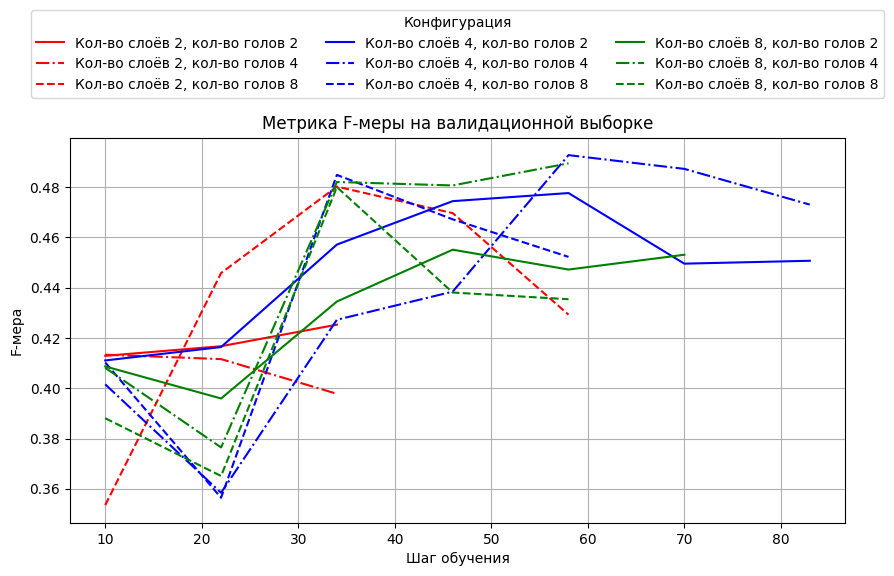

In [ ]:
plt.figure(figsize=(10, 5))
plt.title("Метрика F-меры на валидационной выборке")
plt.xlabel("Шаг обучения")
plt.ylabel("F-мера")

for i in range(9):
    path = pathes[i]
    layers, heads = extract_ij_from_path(path)
    plt.plot(dfs[pathes[i]]["val_f1"].dropna(), label=f"Кол-во слоёв {layers}, кол-во голов {heads}", color=colors[int(math.log2(layers)) - 1], linestyle=linestyles[int(math.log2(heads)) - 1])

plt.grid()
plt.legend(title="Конфигурация", bbox_to_anchor=(0.5, 1.35), loc="upper center", ncol=3)

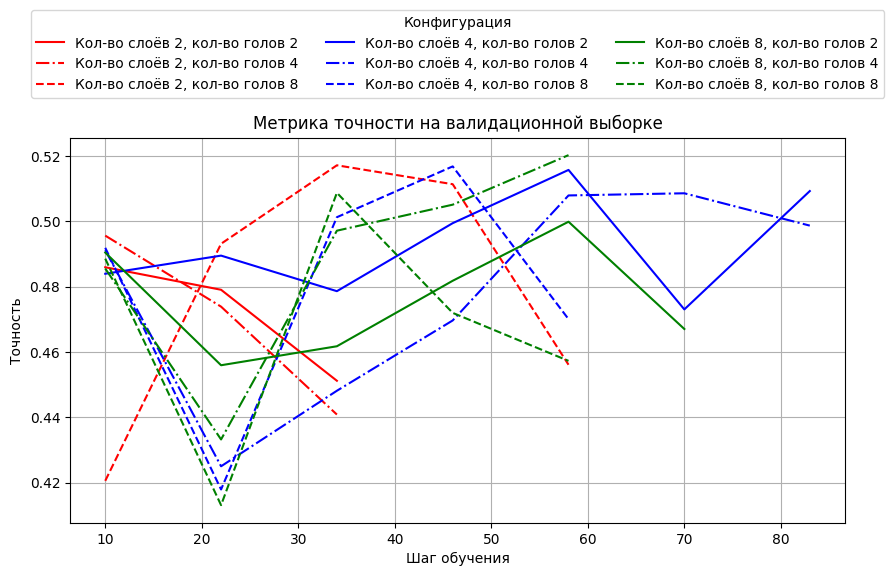

In [ ]:
plt.figure(figsize=(10, 5))
plt.title("Метрика точности на валидационной выборке")
plt.xlabel("Шаг обучения")
plt.ylabel("Точность")

for i in range(9):
    path = pathes[i]
    layers, heads = extract_ij_from_path(path)
    plt.plot(dfs[pathes[i]]["val_acc"].dropna(), label=f"Кол-во слоёв {layers}, кол-во голов {heads}", color=colors[int(math.log2(layers)) - 1], linestyle=linestyles[int(math.log2(heads)) - 1])

plt.grid()
plt.legend(title="Конфигурация", bbox_to_anchor=(0.5, 1.35), loc="upper center", ncol=3)

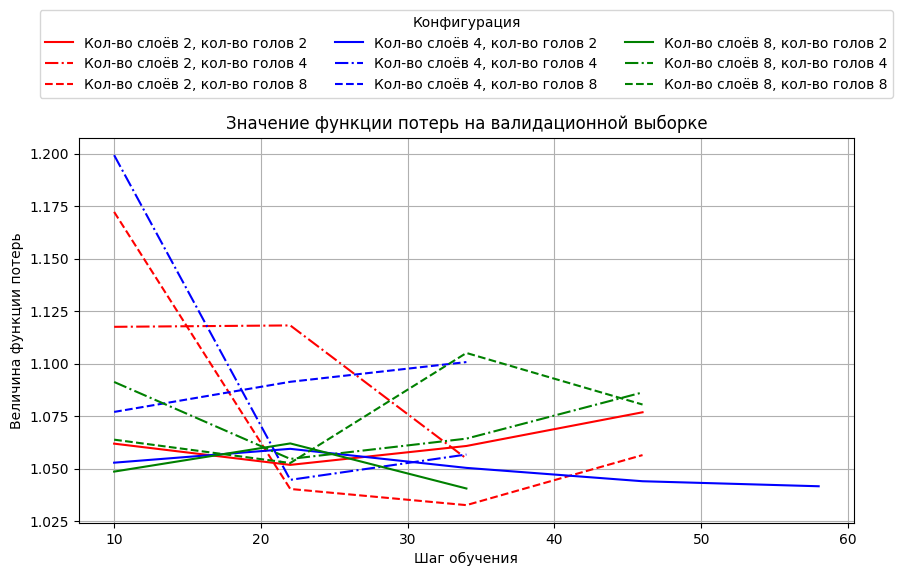

In [ ]:
def extract_ij_from_path(path):
    # Use regex to find the pattern bert_{i}_{j}
    match = re.search(r"conformer_(\d+)_(\d+)", path)
    if match:
        i, j = match.groups()
        return int(i), int(j)

    raise ValueError("Path does not contain a valid bert_{i}_{j} pattern.", path)


plt.figure(figsize=(10, 5))
plt.title("Значение функции потерь на валидационной выборке")
plt.xlabel("Шаг обучения")
plt.ylabel("Величина функции потерь")

for i in range(9, len(pathes)):
    path = pathes[i]
    layers, heads = extract_ij_from_path(path)
    plt.plot(dfs[pathes[i]]["val_loss"].dropna(), label=f"Кол-во слоёв {layers}, кол-во голов {heads}", color=colors[int(math.log2(layers)) - 1], linestyle=linestyles[int(math.log2(heads)) - 1])

plt.grid()
plt.legend(title="Конфигурация", bbox_to_anchor=(0.5, 1.35), loc="upper center", ncol=3)

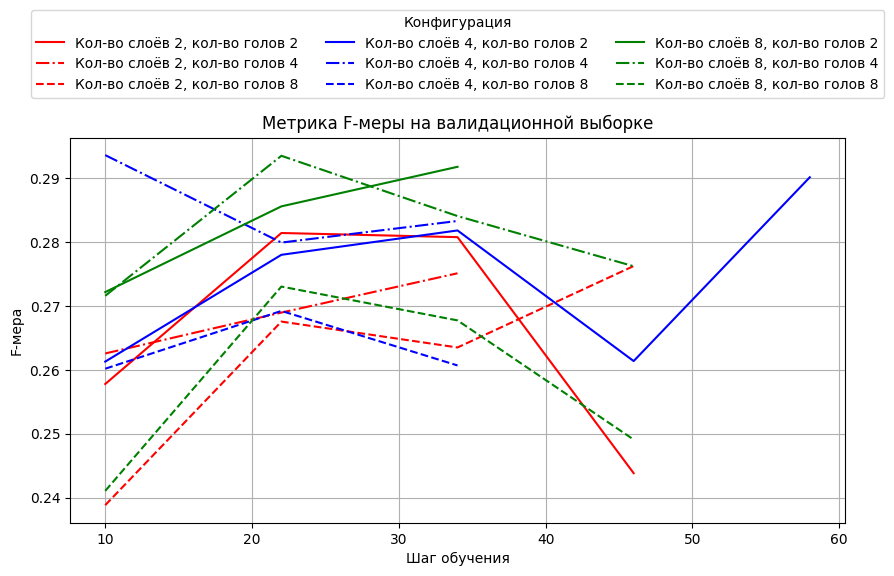

In [ ]:
plt.figure(figsize=(10, 5))
plt.title("Метрика F-меры на валидационной выборке")
plt.xlabel("Шаг обучения")
plt.ylabel("F-мера")

for i in range(9, len(pathes)):
    path = pathes[i]
    layers, heads = extract_ij_from_path(path)
    plt.plot(dfs[pathes[i]]["val_f1"].dropna(), label=f"Кол-во слоёв {layers}, кол-во голов {heads}", color=colors[int(math.log2(layers)) - 1], linestyle=linestyles[int(math.log2(heads)) - 1])

plt.grid()
plt.legend(title="Конфигурация", bbox_to_anchor=(0.5, 1.35), loc="upper center", ncol=3)

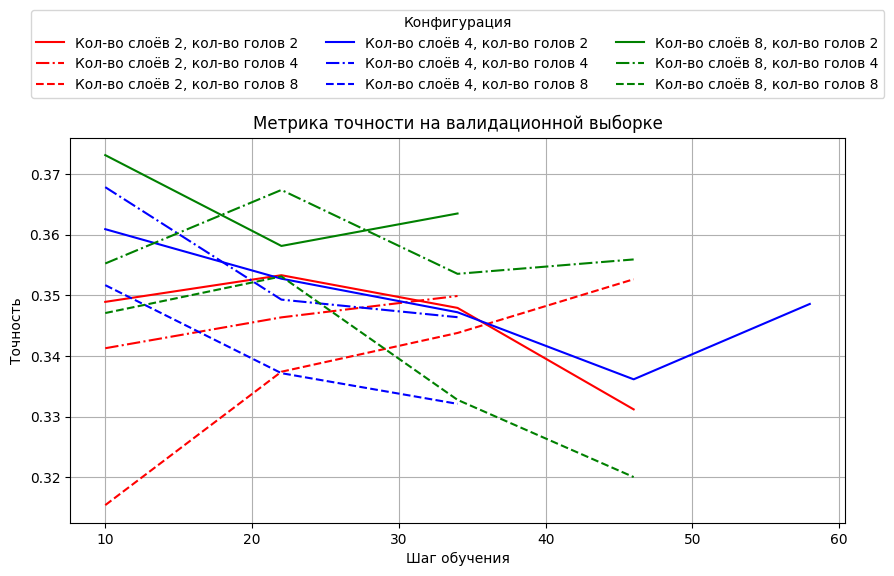

In [ ]:
plt.figure(figsize=(10, 5))
plt.title("Метрика точности на валидационной выборке")
plt.xlabel("Шаг обучения")
plt.ylabel("Точность")

for i in range(9, len(pathes)):
    path = pathes[i]
    layers, heads = extract_ij_from_path(path)
    plt.plot(dfs[pathes[i]]["val_acc"].dropna(), label=f"Кол-во слоёв {layers}, кол-во голов {heads}", color=colors[int(math.log2(layers)) - 1], linestyle=linestyles[int(math.log2(heads)) - 1])

plt.grid()
plt.legend(title="Конфигурация", bbox_to_anchor=(0.5, 1.35), loc="upper center", ncol=3)

In [ ]:
dfs[pathes[0]]["test_f1"].dropna().iloc[0]

np.float64(0.4377311468124389)

In [ ]:
for path in pathes:
    f1 = dfs[path]["test_f1"].dropna().iloc[0]
    acc = dfs[path]["test_acc"].dropna().iloc[0]
    print(f"{path=}; {acc=}, {f1=}")

path='/home/artyom/myprojects/ITMO/DML/logs/bert_2_2/version_0/metrics.csv'; acc=np.float64(0.4646144807338714), f1=np.float64(0.4377311468124389)
path='/home/artyom/myprojects/ITMO/DML/logs/bert_2_4/version_0/metrics.csv'; acc=np.float64(0.4919224083423614), f1=np.float64(0.4114635586738586)
path='/home/artyom/myprojects/ITMO/DML/logs/bert_2_8/version_0/metrics.csv'; acc=np.float64(0.5269578099250793), f1=np.float64(0.4896667003631592)
path='/home/artyom/myprojects/ITMO/DML/logs/bert_4_2/version_0/metrics.csv'; acc=np.float64(0.5361222624778748), f1=np.float64(0.50080406665802)
path='/home/artyom/myprojects/ITMO/DML/logs/bert_4_4/version_0/metrics.csv'; acc=np.float64(0.5174100995063782), f1=np.float64(0.4961796998977661)
path='/home/artyom/myprojects/ITMO/DML/logs/bert_4_8/version_0/metrics.csv'; acc=np.float64(0.5086354613304138), f1=np.float64(0.4908416867256164)
path='/home/artyom/myprojects/ITMO/DML/logs/bert_8_2/version_0/metrics.csv'; acc=np.float64(0.5051465034484863), f1=np.f

In [ ]:
pathes = [
    "/home/artyom/myprojects/ITMO/DML/logs/early_fusion/version_5/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/early_fusion_v2/version_2/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/late_fusion/version_1/metrics.csv",
    "/home/artyom/myprojects/ITMO/DML/logs/cross-attn-fusion/version_1/metrics.csv",
]

dfs = {}
for file in pathes:
    dfs[str(file)] = pd.read_csv(file)
dfs[pathes[0]]

,epoch,step,test_acc,test_f1,test_loss,test_precision,test_recall,test_roc-auc,train_acc,train_f1,train_loss,train_precision,train_recall,train_roc-auc,val_acc,val_f1,val_loss,val_precision,val_recall,val_roc-auc
0,0,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.405617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.280435,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.985224,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.129799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.879843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0,299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.950727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.740438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.954746,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0,449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.876323,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0,499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.549094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


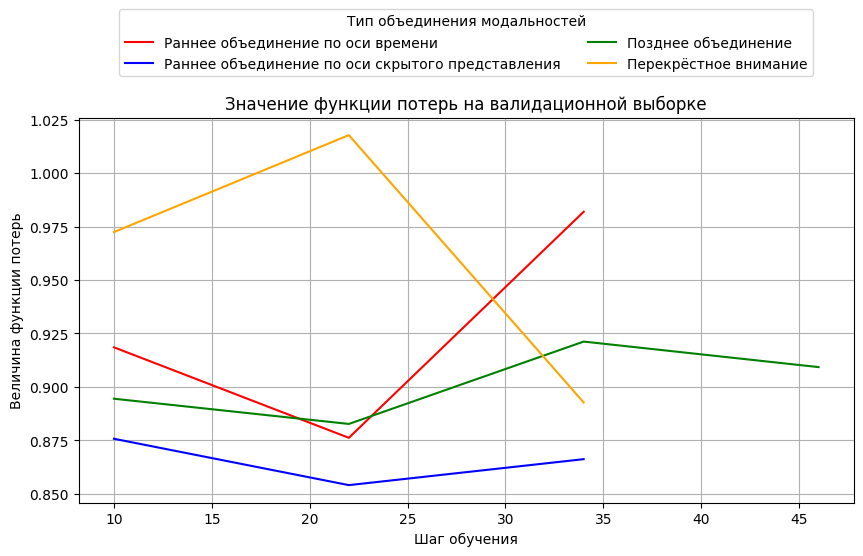

In [ ]:
plt.figure(figsize=(10, 5))
plt.title("Значение функции потерь на валидационной выборке")
plt.xlabel("Шаг обучения")
plt.ylabel("Величина функции потерь")

fusions = ["Раннее объединение по оси времени", "Раннее объединение по оси скрытого представления", "Позднее объединение", "Перекрёстное внимание"]
colors = ["red", "blue", "green", "orange"]
for i in range(len(pathes)):
    path = pathes[i]
    plt.plot(dfs[pathes[i]]["val_loss"].dropna(), label=fusions[i], color=colors[i])
plt.grid()
plt.legend(title="Тип объединения модальностей", bbox_to_anchor=(0.5, 1.3), loc="upper center", ncol=len(fusions) / 2)

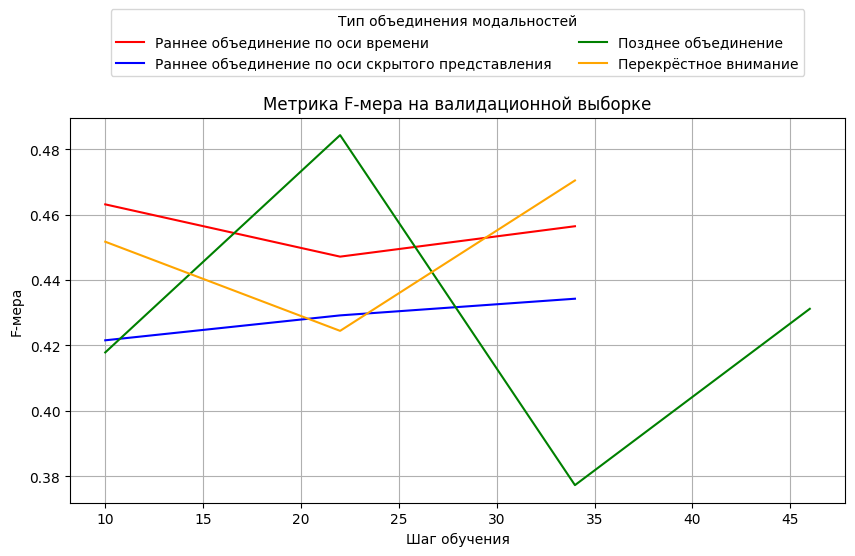

In [ ]:
plt.figure(figsize=(10, 5))
plt.title("Метрика F-мера на валидационной выборке")
plt.xlabel("Шаг обучения")
plt.ylabel("F-мера")

for i in range(len(pathes)):
    path = pathes[i]
    plt.plot(dfs[pathes[i]]["val_f1"].dropna(), label=fusions[i], color=colors[i])
plt.grid()
plt.legend(title="Тип объединения модальностей", bbox_to_anchor=(0.5, 1.3), loc="upper center", ncol=len(fusions) / 2)

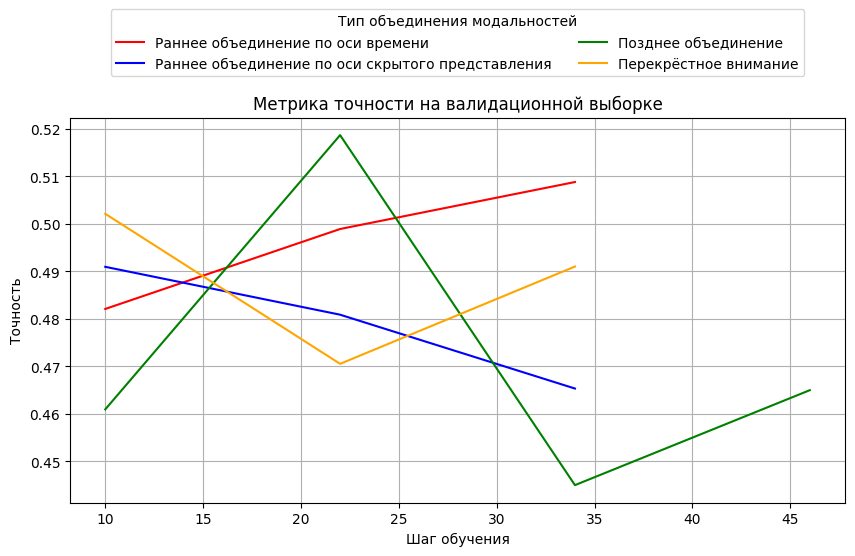

In [ ]:
plt.figure(figsize=(10, 5))
plt.title("Метрика точности на валидационной выборке")
plt.xlabel("Шаг обучения")
plt.ylabel("Точность")

for i in range(len(pathes)):
    path = pathes[i]
    plt.plot(dfs[pathes[i]]["val_acc"].dropna(), label=fusions[i], color=colors[i])
plt.grid()
plt.legend(title="Тип объединения модальностей", bbox_to_anchor=(0.5, 1.3), loc="upper center", ncol=len(fusions) / 2)

In [ ]:
for path in pathes:
    f1 = dfs[path]["test_f1"].dropna().iloc[0]
    acc = dfs[path]["test_acc"].dropna().iloc[0]
    print(f"{path=}; {acc=}, {f1=}")

path='/home/artyom/myprojects/ITMO/DML/logs/early_fusion/version_5/metrics.csv'; acc=np.float64(0.4999673366546631), f1=np.float64(0.4763230085372925)
path='/home/artyom/myprojects/ITMO/DML/logs/early_fusion_v2/version_2/metrics.csv'; acc=np.float64(0.4681603908538818), f1=np.float64(0.4351685047149658)
path='/home/artyom/myprojects/ITMO/DML/logs/late_fusion/version_1/metrics.csv'; acc=np.float64(0.5136163830757141), f1=np.float64(0.4825079143047333)
path='/home/artyom/myprojects/ITMO/DML/logs/cross-attn-fusion/version_1/metrics.csv'; acc=np.float64(0.4836954176425934), f1=np.float64(0.46418496966362)
